### Import packages and define paths

In [ ]:
from pathlib import Path
import json
from sentence_transformers import SentenceTransformer
import numpy as np
import random
import matplotlib.pyplot as plt
import numpy as np

/Users/tildeidunsloth/Desktop/Thesis/Thesis_project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define project and data paths
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/cleaned"

sci_fi_data_path = DATA_DIR / "sci_fi_stories_cleaned.jsonl"
romance_data_path = DATA_DIR / "romance_stories_cleaned.jsonl"
literary_fiction_data_path = DATA_DIR / "lit_fiction_stories_cleaned.jsonl"

### Load data and model

In [5]:
model = SentenceTransformer("google/embeddinggemma-300m")
tokenizer = model.tokenizer

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 1428.75it/s, Materializing param=norm.weight]                                


In [6]:
random.seed(42)  # for reproducibility

In [7]:
def load_jsonl_data(file_path):
    with open(file_path, 'r') as f:
        stories = [json.loads(line) for line in f]
    return stories

In [8]:
lit_fiction_stories = load_jsonl_data(literary_fiction_data_path)
romance_stories = load_jsonl_data(romance_data_path)
sci_fi_stories = load_jsonl_data(sci_fi_data_path)

### Selecting random and similar prompt stories

In [9]:
# select 100 random stories
lit_fiction_stories_random = random.sample(lit_fiction_stories, 100)

# select 100 stories with event = "discovers something new" and context = "on vacation"
lit_fiction_stories_same_event_context = [story for story in lit_fiction_stories if story['event'] == "discovers something new" and story['context'] == "on vacation"][:18]

In [10]:
# select 100 random stories
sci_fi_stories_random = random.sample(sci_fi_stories, 100)

# select 100 stories with event = "discovers something new" and context = "on vacation"
sci_fi_stories_same_event_context = [story for story in sci_fi_stories if story['event'] == "discovers something new" and story['context'] == "on vacation"][:18]

In [11]:
# select 100 random stories
romance_stories_random = random.sample(romance_stories, 100)

# select 100 stories with event = "discovers something new" and context = "on vacation"
romance_stories_same_event_context = [story for story in romance_stories if story['event'] == "discovers something new" and story['context'] == "on vacation"][:18]

In [42]:
all_stories = romance_stories_random + romance_stories_same_event_context + lit_fiction_stories_random + lit_fiction_stories_same_event_context + sci_fi_stories_random + sci_fi_stories_same_event_context

In [ ]:
# check how many stories exceed 2048 tokens
token_lengths = [len(tokenizer.encode(s["story"])) for s in all_stories]

print(f"Max: {max(token_lengths)}")
print(f"Min: {min(token_lengths)}")
print(f"Median: {np.median(token_lengths):.0f}")
print(f"Stories exceeding 2048 tokens: {sum(l > 2048 for l in token_lengths)}")

Max: 3607
Min: 1334
Median: 2038
Stories exceeding 2048 tokens: 172


In [ ]:
# describe excess tokens for stories that exceed 2048 tokens
truncated = [l for l in token_lengths if l > 2048]
excess = [l - 2048 for l in truncated]
print(f"Median excess tokens: {np.median(excess):.0f}")
print(f"Mean excess tokens: {np.mean(excess):.0f}")
print(f"Max excess tokens: {max(excess):.0f}")

Median excess tokens: 185
Mean excess tokens: 261
Max excess tokens: 1559


### Functions

In [ ]:
# function for embedding a story
def embed_story(text, model, max_tokens=2048):
    return model.encode_document([text])[0]

In [26]:
# function for extracting story texts and embedding them
def extract_and_embed(stories, model):
    story_texts = [item["story"] for item in stories]
    embeddings = [embed_story(text, model) for text in story_texts]
    return embeddings

In [29]:
def compute_semantic_distance_matrix(embeddings):
    
    sim_matrix = model.similarity(embeddings, embeddings).cpu().numpy()
    distance_matrix = 1 - sim_matrix
    
    return distance_matrix, sim_matrix

In [30]:
def mean_corpus_distance(distance_matrix):
    n = sim_matrix.shape[0]
    upper = sim_matrix[np.triu_indices(n, k=1)] # only take upper triangle (excluding diagonal)
    return np.mean(upper)

In [36]:
def compute_cross_genre_similarity(embeddings_a, embeddings_b):
    sim = model.similarity(embeddings_a, embeddings_b).cpu().numpy()
    return np.mean(sim) # no duplicate half, so simply average the whole matrix


### Results

In [ ]:
embeddings_lit_fic_random = extract_and_embed(lit_fiction_stories_random, model)
distance_matrix_lit_fic, sim_matrix_lit_fic = compute_semantic_distance_matrix(embeddings_lit_fic_random)
mean_similarity_random_lit_fic = mean_corpus_distance(sim_matrix_lit_fic)
print(f"Mean semantic similarity (random lit fic): {mean_similarity_random_lit_fic:.4f}")

embeddings_sci_fi_random = extract_and_embed(sci_fi_stories_random, model)
distance_matrix_sci_fi, sim_matrix_sci_fi = compute_semantic_distance_matrix(embeddings_sci_fi_random)
mean_similarity_random_sci_fi = mean_corpus_distance(sim_matrix_sci_fi)
print(f"Mean semantic similarity (random sci-fi): {mean_similarity_random_sci_fi:.4f}")

embeddings_romance_random = extract_and_embed(romance_stories_random, model)
distance_matrix_romance, sim_matrix_romance = compute_semantic_distance_matrix(embeddings_romance_random)
mean_similarity_random_romance = mean_corpus_distance(sim_matrix_romance)
print(f"Mean semantic similarity (random romance): {mean_similarity_random_romance:.4f}")

Mean semantic similarity (random lit fic): 0.5941
Mean semantic similarity (random sci-fi): 0.6379
Mean semantic similarity (random romance): 0.5981


In [ ]:
embeddings_lit_fic_same_event_context = extract_and_embed(lit_fiction_stories_same_event_context, model)
distance_matrix_lit_fic_same, sim_matrix_lit_fic_same = compute_semantic_distance_matrix(embeddings_lit_fic_same_event_context)
mean_distance_same_event_context_lit_fic = mean_corpus_distance(distance_matrix_lit_fic_same)
print(f"Mean semantic distance (same event context lit fic): {mean_distance_same_event_context_lit_fic:.4f}")

embeddings_sci_fi_same_event_context = extract_and_embed(sci_fi_stories_same_event_context, model)
distance_matrix_sci_fi_same, sim_matrix_sci_fi_same = compute_semantic_distance_matrix(embeddings_sci_fi_same_event_context)
mean_distance_same_event_context_sci_fi = mean_corpus_distance(distance_matrix_sci_fi_same)
print(f"Mean semantic distance (same event context sci-fi): {mean_distance_same_event_context_sci_fi:.4f}")

embeddings_romance_same_event_context = extract_and_embed(romance_stories_same_event_context, model)
distance_matrix_romance, sim_matrix_romance = compute_semantic_distance_matrix(embeddings_romance_same_event_context)
mean_distance_same_event_context_romance = mean_corpus_distance(distance_matrix_romance)
print(f"Mean semantic distance (same event context romance): {mean_distance_same_event_context_romance:.4f}")

Mean semantic distance (same event context lit fic): 0.6604
Mean semantic distance (same event context sci-fi): 0.6627
Mean semantic distance (same event context romance): 0.6757


### Results across genres

In [37]:
compute_cross_genre_similarity(embeddings_lit_fic_random, embeddings_romance_random), compute_cross_genre_similarity(embeddings_romance_random, embeddings_sci_fi_random), compute_cross_genre_similarity(embeddings_lit_fic_random, embeddings_sci_fi_random)

(0.57509995, 0.5311024, 0.5438575)

In [38]:
compute_cross_genre_similarity(embeddings_lit_fic_same_event_context, embeddings_romance_same_event_context), compute_cross_genre_similarity(embeddings_romance_same_event_context, embeddings_sci_fi_same_event_context), compute_cross_genre_similarity(embeddings_lit_fic_same_event_context, embeddings_sci_fi_same_event_context)

(0.64882284, 0.5849686, 0.5854041)

### Inspect one example visually

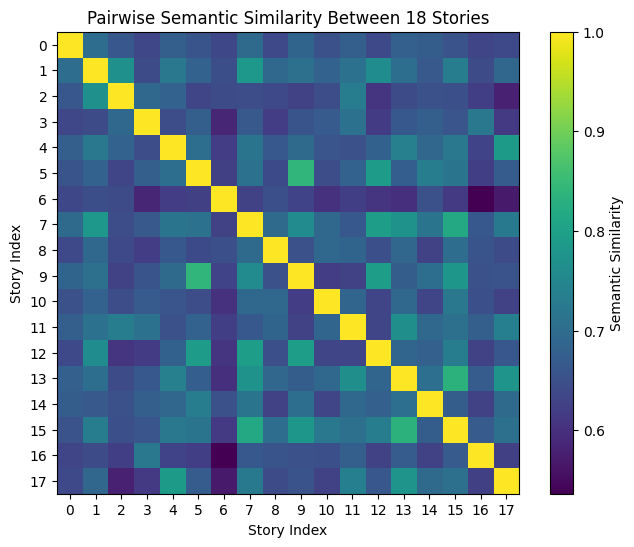

In [ ]:
plt.figure(figsize=(8, 6))
im = plt.imshow(sim_matrix_sci_fi_same, cmap="viridis") 

plt.colorbar(im, label="Semantic Similarity")
plt.title("Pairwise Semantic Similarity Between 18 Stories")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.xticks(ticks=np.arange(18))
plt.yticks(ticks=np.arange(18))
plt.show()